# Payment Transaction Anomaly Classification — Capstone Notebook

**Problem 26 — FinTech — Binary Classification (10-day capstone)**

This notebook is the end-to-end analysis notebook for the project. It calls
into the reusable modules under `src/` (`data_loader`, `preprocessing`,
`features`, `train`, `evaluate`) rather than duplicating logic here, so the
notebook and the production pipeline (`src/train.py`, the Streamlit app)
never drift apart.

> **No fabricated results.** Every output cell in this notebook reflects
> whatever dataset is actually present in `data/raw/` when the notebook is
> run. If no dataset has been placed yet, the loading cell below will raise
> a clear error with instructions instead of showing fake numbers.
> See `data/README.md` for the recommended dataset and column mapping.


In [2]:
# Setup
import sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    sys.path.append(str(Path.cwd().parent))
else:
    sys.path.append(str(Path.cwd()))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.utils import DatasetNotFoundError

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

config.ensure_directories()


## Step 1 — Data Understanding

In [3]:
from src.data_loader import (
    load_raw_data,
    basic_overview,
    missing_value_report,
    duplicate_report,
    unique_value_counts,
    descriptive_statistics,
    target_distribution,
    class_imbalance_ratio,
    outlier_report_iqr,
    flag_potential_leakage_columns,
)

try:
    df = load_raw_data()
    print("Dataset loaded successfully.")
except DatasetNotFoundError as e:
    df = None
    print(e)


2026-09-30 19:07:27 | INFO     | src.data_loader | Loaded dataset from E:\payment-transaction-anomaly-classification\data\raw\transactions.csv — shape (318131, 11)


Dataset loaded successfully.


In [4]:
if df is not None:
    overview = basic_overview(df)
    print(f"Rows: {overview['n_rows']}, Columns: {overview['n_columns']}")
    print(df.dtypes)
    df.head()


Rows: 318131, Columns: 11
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [5]:
if df is not None:
    display(missing_value_report(df))


,n_missing,pct_missing
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


In [6]:
if df is not None:
    print(duplicate_report(df))


{'n_duplicate_rows': 0, 'pct_duplicate_rows': 0.0}


In [7]:
if df is not None:
    display(unique_value_counts(df))


nameOrig          318106
amount            314523
nameDest          260482
newbalanceDest    194790
oldbalanceDest    182908
oldbalanceOrg     144998
newbalanceOrig    136815
step                 566
type                   5
isFraud                2
isFlaggedFraud         1
dtype: int64

In [8]:
if df is not None:
    display(descriptive_statistics(df))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,318131.0,NaN,NaN,NaN,243.677318,142.491218,1.0,156.0,240.0,335.0,741.0
type,318131,5,CASH_OUT,111969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,318131.0,NaN,NaN,NaN,180928.126814,617818.063149,0.41,13410.4,74971.25,208941.975,69886731.3
nameOrig,318131,318106,C201890777,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,318131.0,NaN,NaN,NaN,830760.362362,2883146.767652,0.0,0.0,13703.0,106701.795,37919816.48
newbalanceOrig,318131.0,NaN,NaN,NaN,851981.012544,2919005.472898,0.0,0.0,0.0,142405.175,37950093.25
nameDest,318131,260482,C929266212,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,318131.0,NaN,NaN,NaN,1109108.243215,3534026.870633,0.0,0.0,132695.87,949116.99,355185537.06
newbalanceDest,318131.0,NaN,NaN,NaN,1234387.165376,3810364.32773,0.0,0.0,214967.64,1115224.495,355380483.53
isFraud,318131.0,NaN,NaN,NaN,0.001292,0.03592,0.0,0.0,0.0,0.0,1.0


In [9]:
if df is not None:
    try:
        dist = target_distribution(df)
        display(dist)
        print("Class imbalance ratio (majority:minority):", class_imbalance_ratio(df))
    except (KeyError, ValueError) as e:
        print(e)


,count,pct
isFraud,,
0,317720,99.87
1,411,0.13


Class imbalance ratio (majority:minority): 773.04


In [10]:
if df is not None:
    leakage_candidates = flag_potential_leakage_columns(df)
    print("Heuristically flagged potential-leakage columns (verify manually):", leakage_candidates)


Heuristically flagged potential-leakage columns (verify manually): ['isFlaggedFraud']


**Observation / Implication template** — fill this in with the *actual*
findings once the dataset is loaded above. Do not pre-fill interpretations
before the numbers exist.

## Step 2 & 3 — Data Cleaning and Leakage-Prevention Setup

In [11]:
from src.preprocessing import drop_duplicate_rows, coerce_dtypes

if df is not None:
    df_clean, n_dropped = drop_duplicate_rows(df)
    print(f"Dropped {n_dropped} duplicate rows.")
    df_clean = coerce_dtypes(df_clean)
    df_clean.dtypes


Dropped 0 duplicate rows.


**Note on leakage prevention:** the train/test split happens in
`src/train.py -> prepare_data()` BEFORE feature engineering and BEFORE any
preprocessing is fit, so nothing in this notebook accidentally fits a
transform on the full dataset. This notebook re-uses that exact function
below rather than re-implementing the split here.

## Step 4 — Exploratory Data Analysis

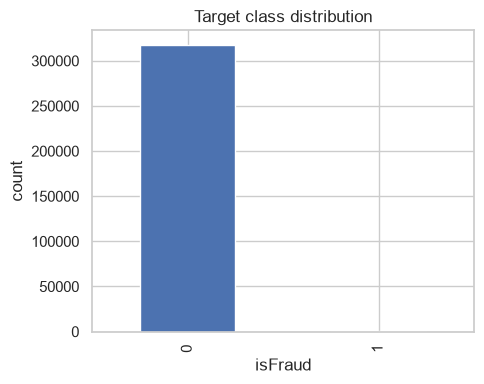

In [12]:
from src.config import FEATURE_CONFIG

if df is not None:
    target_col = FEATURE_CONFIG["target"]
    amount_col = FEATURE_CONFIG["amount"]

    fig, ax = plt.subplots(figsize=(5, 4))
    df_clean[target_col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title("Target class distribution")
    ax.set_xlabel(target_col)
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "target_distribution.png", dpi=150)
    plt.show()


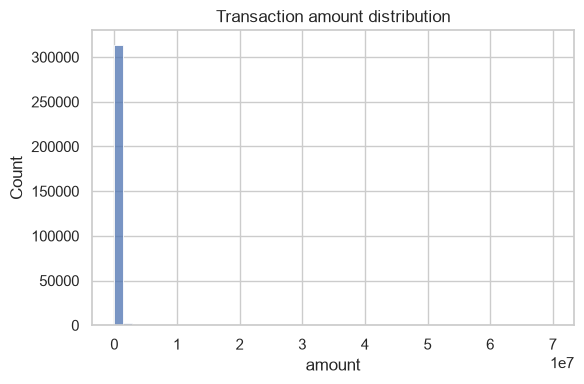

In [13]:
if df is not None and amount_col in df_clean.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(df_clean[amount_col], bins=50, ax=ax)
    ax.set_title("Transaction amount distribution")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "amount_distribution.png", dpi=150)
    plt.show()


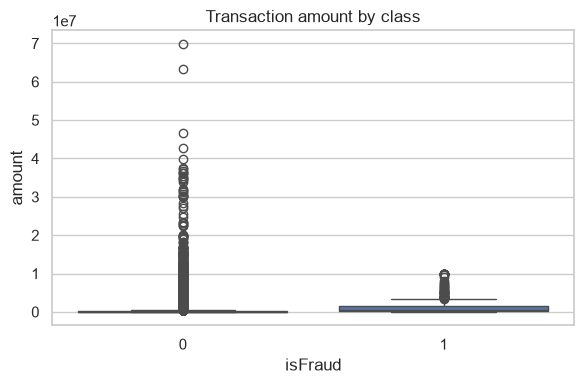

In [14]:
if df is not None and amount_col in df_clean.columns and target_col in df_clean.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(data=df_clean, x=target_col, y=amount_col, ax=ax)
    ax.set_title("Transaction amount by class")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "amount_by_class.png", dpi=150)
    plt.show()


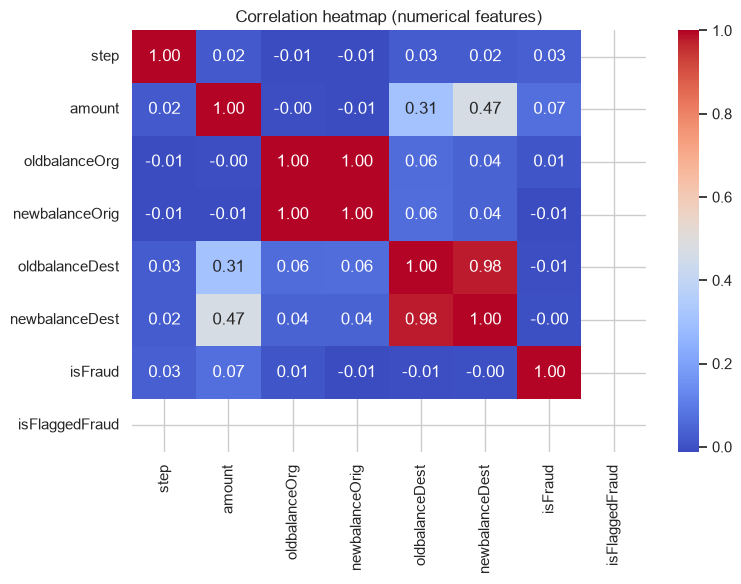

In [15]:
if df is not None:
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) > 1:
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
        ax.set_title("Correlation heatmap (numerical features)")
        plt.tight_layout()
        plt.savefig(config.FIGURES_DIR / "correlation_heatmap.png", dpi=150)
        plt.show()


**Observation:** *[fill in after running the cells above on the real
dataset — describe what the plots actually show]*

**Implication:** *[fill in — note this is association, not causation, per
the project's interpretability guidance in `src/evaluate.py`]*

## Step 5 — Feature Engineering

In [16]:
from src.features import engineer_features

if df is not None:
    df_features = engineer_features(df_clean)
    df_features.head()


See `src/features.py` docstrings for the formula, purpose, prediction-time
availability, and leakage-risk assessment of every engineered feature
(`hour_of_day`, `day_of_week`, `amount_log`,
`amount_deviation_from_history`, `frequency_bucket`).

## Steps 6–13 — Baseline, Model Comparison, Tuning, Final Model, Pipeline Saving

In [ ]:
from src.train import run_training_pipeline

# This single call performs Steps 6 (baseline), 7 (comparison), 8 (imbalance
# handled via class_weight in the param grids), 11 (GridSearchCV tuning),
# 12 (final model selection) and 13 (saving the pipeline) — see
# src/train.py for the full, documented implementation.
if df is not None:
    results, final_model_name = run_training_pipeline()
    print("Final model selected:", final_model_name)
else:
    print("Skipping training — no dataset present yet. See data/README.md.")


2026-09-30 19:07:37 | INFO     | src.data_loader | Loaded dataset from E:\payment-transaction-anomaly-classification\data\raw\transactions.csv — shape (318131, 11)
2026-09-30 19:07:38 | INFO     | src.train | Dropped 0 duplicate rows.
2026-09-30 19:07:38 | INFO     | src.train | Class imbalance ratio (majority:minority) = 773.04:1
2026-09-30 19:07:39 | INFO     | src.train | --- Training logistic_regression ---
2026-09-30 19:08:10 | INFO     | src.train | [logistic_regression] best_params={'model__C': 10.0, 'model__class_weight': 'balanced'} best_cv_f1=0.0021 (tuned in 31.4s)
2026-09-30 19:08:10 | INFO     | src.evaluate | [logistic_regression] metrics: {'accuracy': 0.5617898062143429, 'precision': 0.0014347202295552368, 'recall': 0.4878048780487805, 'f1': 0.0028610256777054574, 'roc_auc': 0.523392487367316}
2026-09-30 19:08:10 | INFO     | src.train | --- Training knn ---


In [ ]:
if df is not None:
    import pandas as pd
    comparison_rows = []
    for name, r in results.items():
        row = {"model": name, **r["metrics"], "training_time_s": r["training_time_seconds"]}
        comparison_rows.append(row)
    comparison_df = pd.DataFrame(comparison_rows).set_index("model")
    display(comparison_df)


## Step 9 — Error Analysis (Focus: False Positives)

In [ ]:
from src.evaluate import error_breakdown, error_case_dataframe, false_positive_pattern_summary
from src.train import prepare_data
import joblib

if df is not None:
    X_train, X_test, y_train, y_test, numerical_cols, categorical_cols = prepare_data()
    final_pipeline = joblib.load(config.FINAL_MODEL_PATH)
    y_pred = final_pipeline.predict(X_test)

    breakdown = error_breakdown(y_test, y_pred)
    print(breakdown)

    error_df = error_case_dataframe(X_test, y_test, y_pred)
    error_df.to_csv(config.ERROR_ANALYSIS_DIR / "error_cases.csv", index=False)

    pattern_summary = false_positive_pattern_summary(
        error_df, group_cols=[c for c in categorical_cols if c in error_df.columns]
    )
    pattern_summary


In [ ]:
if df is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.countplot(data=error_df, x="error_type", ax=ax)
    ax.set_title("Prediction outcome breakdown (TP / TN / FP / FN)")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "error_breakdown.png", dpi=150)
    plt.show()


**Why false positives matter here:** a false positive is a routine
transaction incorrectly flagged as anomalous. In a real transaction
monitoring system this would waste investigator time and could
inconvenience a legitimate customer — but note this project is an
educational prototype and these are illustrative, not measured,
operational consequences unless the dataset/domain specifies them.

## Step 10 — Model Interpretability

In [ ]:
from src.evaluate import logistic_regression_coefficients, tree_feature_importances, interpretation_note

if df is not None:
    lr_coefs = logistic_regression_coefficients(final_pipeline)
    tree_importances = tree_feature_importances(final_pipeline)
    if lr_coefs is not None:
        display(lr_coefs.head(15))
    if tree_importances is not None:
        display(tree_importances.head(15))
    print(interpretation_note())


## Step 12 — Final Model Justification

*Fill in after running the training cell above:* summarize, in your own
words, why the model chosen by `select_final_model()` was selected —
referencing its actual recall, F1, interpretability, and complexity versus
the other two baselines. Do not write this section until the real numbers
exist.

## Reproducibility checklist for this notebook

- [ ] Dataset placed at `data/raw/transactions.csv` (or `config.py` updated)
- [ ] `src/config.py -> FEATURE_CONFIG` matches the real dataset's columns
- [ ] All cells above run top-to-bottom without errors
- [ ] Figures saved under `reports/figures/`
- [ ] `models/final_model.joblib` and `models/preprocessing_pipeline.joblib` exist
- [ ] `reports/metrics/model_comparison.json` and `models/model_card.json` exist
- [ ] Observation/Implication and Final Model Justification sections filled in with real findings
